# Постановка задачи

Набор данных «Глобальный индекс искусственного интеллекта» включает в себя сам Глобальный индекс искусственного интеллекта и семь показателей, влияющих на индекс, по 62 странам, а также общую информацию о странах (регион, кластер, группа доходов и политический режим).

Глобальный индекс развития искусственного интеллекта — это первый индекс, позволяющий оценить уровень инвестиций, инноваций и внедрения искусственного интеллекта в разных странах.

Талант, инфраструктура и операционная среда — это факторы, определяющие группу показателей внедрения ИИ, которая отражает применение искусственного интеллекта профессионалами в различных сферах, таких как бизнес, государственное управление и общественная деятельность.

* Сделать Разведочный анализ данных
*  Написать описание датасета
*  Отметить важность признаков
*  Кластеризация (3 метода), метрики, визуализация.

## Импорт библиотек и загрузка датасета

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("AI_index_db.csv")

## Описание датасета

In [4]:
df.head(10)

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
0,United States of America,100.00,94.02,64.56,100.00,100.00,77.39,100.00,100.00,Americas,Power players,High,Liberal democracy
1,China,16.51,100.00,91.57,71.42,79.97,94.87,44.02,62.92,Asia-Pacific,Power players,Upper middle,Closed autocracy
2,United Kingdom,39.65,71.43,74.65,36.50,25.03,82.82,18.91,40.93,Europe,Traditional champions,High,Liberal democracy
3,Canada,31.28,77.05,93.94,30.67,25.78,100.00,14.88,40.19,Americas,Traditional champions,High,Liberal democracy
4,Israel,35.76,67.58,82.44,32.63,27.96,43.91,27.33,39.89,Middle East,Rising stars,High,Liberal democracy
5,Singapore,39.38,84.30,43.15,37.67,22.55,79.82,15.07,38.67,Asia-Pacific,Rising stars,High,Electoral democracy
6,South Korea,14.54,85.23,68.86,26.66,77.25,87.50,5.41,38.60,Asia-Pacific,Rising stars,High,Liberal democracy
7,The Netherlands,33.83,81.99,88.05,25.54,30.17,62.35,4.97,36.35,Europe,Rising stars,High,Liberal democracy
8,Germany,27.63,77.22,70.22,35.84,24.79,84.65,8.29,36.04,Europe,Traditional champions,High,Liberal democracy
9,France,28.32,77.15,80.02,25.48,21.44,91.20,7.65,34.42,Europe,Traditional champions,High,Liberal democracy


* Country — государство.
* Talent — кадры.
* Infrastructure — инфраструктура.
* Operating Environment — среда.
* Research — исследования.
* Development — развитие.
* Government Strategy — стратегия.
* Commercial — коммерция.
* Total score — оценка.
* Region — регион.
* Cluster — кластер.
* Income group — группа.
* Political regime — режим

##  Разведочный анализ данных

In [5]:
# объём данных (строк и столбцов - объектов и признаков)
df.shape

(62, 13)

In [6]:
# выводим типы данных
df.dtypes

Country                   object
Talent                   float64
Infrastructure           float64
Operating Environment    float64
Research                 float64
Development              float64
Government Strategy      float64
Commercial               float64
Total score              float64
Region                    object
Cluster                   object
Income group              object
Political regime          object
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Country                62 non-null     object 
 1   Talent                 62 non-null     float64
 2   Infrastructure         62 non-null     float64
 3   Operating Environment  62 non-null     float64
 4   Research               62 non-null     float64
 5   Development            62 non-null     float64
 6   Government Strategy    62 non-null     float64
 7   Commercial             62 non-null     float64
 8   Total score            62 non-null     float64
 9   Region                 62 non-null     object 
 10  Cluster                62 non-null     object 
 11  Income group           62 non-null     object 
 12  Political regime       62 non-null     object 
dtypes: float64(8), object(5)
memory usage: 6.4+ KB


В данном датасете пустых и нулевых значений нет.  Типы даные: float64(8), object(5)

In [8]:
# имена колонок в виде списка
df.columns

Index(['Country', 'Talent', 'Infrastructure', 'Operating Environment',
       'Research', 'Development', 'Government Strategy', 'Commercial',
       'Total score', 'Region', 'Cluster', 'Income group', 'Political regime'],
      dtype='object')

In [9]:
for col in df.columns:
    print('Кол-во пропусков в колонке %s = %d' % (col, df[col].isna().sum()))

Кол-во пропусков в колонке Country = 0
Кол-во пропусков в колонке Talent = 0
Кол-во пропусков в колонке Infrastructure = 0
Кол-во пропусков в колонке Operating Environment = 0
Кол-во пропусков в колонке Research = 0
Кол-во пропусков в колонке Development = 0
Кол-во пропусков в колонке Government Strategy = 0
Кол-во пропусков в колонке Commercial = 0
Кол-во пропусков в колонке Total score = 0
Кол-во пропусков в колонке Region = 0
Кол-во пропусков в колонке Cluster = 0
Кол-во пропусков в колонке Income group = 0
Кол-во пропусков в колонке Political regime = 0


In [10]:
df.isnull().sum()

Country                  0
Talent                   0
Infrastructure           0
Operating Environment    0
Research                 0
Development              0
Government Strategy      0
Commercial               0
Total score              0
Region                   0
Cluster                  0
Income group             0
Political regime         0
dtype: int64

Так же в нашем датасете отсутствуют пропущенные значения

In [12]:
df.duplicated().sum()

np.int64(0)

Дубликатов не выявлено.

In [13]:
# сколько уникальных значений в колонке Country? 
df['Country'].nunique()

62

In [14]:
# Какие это значения?
df['Country'].unique()

array(['United States of America', 'China', 'United Kingdom', 'Canada',
       'Israel', 'Singapore', 'South Korea', 'The Netherlands', 'Germany',
       'France', 'Australia', 'Ireland', 'Finland', 'Denmark',
       'Luxembourg', 'Japan', 'India', 'Switzerland', 'Sweden',
       'Hong Kong', 'Spain', 'Austria', 'Estonia', 'Taiwan', 'Norway',
       'Saudi Arabia', 'Belgium', 'Poland', 'Slovenia', 'New Zealand',
       'Italy', 'Russia', 'Malta', 'United Arab Emirates', 'Portugal',
       'Czech Republic', 'Iceland', 'Lithuania', 'Brazil', 'Greece',
       'Slovakia', 'Hungary', 'Malaysia', 'Mexico', 'Chile', 'Argentina',
       'Qatar', 'Turkey', 'Colombia', 'Uruguay', 'Bahrain', 'Vietnam',
       'Indonesia', 'Tunisia', 'South Africa', 'Morocco', 'Armenia',
       'Sri Lanka', 'Egypt', 'Kenya', 'Nigeria', 'Pakistan'], dtype=object)

In [15]:
# описательная статистика для всех (числовых) признаков
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Talent,62.0,16.803065,15.214963,0.0,7.3650,13.445,24.5675,100.0
Infrastructure,62.0,63.503710,20.217525,0.0,55.8575,65.230,75.9475,100.0
Operating Environment,62.0,66.925484,20.000424,0.0,58.1075,69.505,80.5000,100.0
Research,62.0,16.610000,17.413996,0.0,3.0325,12.930,25.4125,100.0
Development,62.0,14.824677,19.419279,0.0,1.2025,9.005,19.9800,100.0
Government Strategy,62.0,57.865645,26.252448,0.0,41.0300,63.930,77.9525,100.0
Commercial,62.0,6.171935,14.029632,0.0,0.6975,2.585,5.3075,100.0
Total score,62.0,23.914677,15.123586,0.0,14.8050,23.220,30.4875,100.0


In [16]:
df.describe(include="all")

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Cluster,Income group,Political regime
count,62,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62.000000,62,62,62,62
unique,62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,5,3,4
top,United States of America,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Europe,Waking up,High,Liberal democracy
freq,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,29,40,43,27
mean,NaN,16.803065,63.503710,66.925484,16.610000,14.824677,57.865645,6.171935,23.914677,NaN,NaN,NaN,NaN
std,NaN,15.214963,20.217525,20.000424,17.413996,19.419279,26.252448,14.029632,15.123586,NaN,NaN,NaN,NaN
min,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN
25%,NaN,7.365000,55.857500,58.107500,3.032500,1.202500,41.030000,0.697500,14.805000,NaN,NaN,NaN,NaN
50%,NaN,13.445000,65.230000,69.505000,12.930000,9.005000,63.930000,2.585000,23.220000,NaN,NaN,NaN,NaN
75%,NaN,24.567500,75.947500,80.500000,25.412500,19.980000,77.952500,5.307500,30.487500,NaN,NaN,NaN,NaN



*   **Country** — чаще всего встречается "United States of America", всего уникальных стран: 62, среднее значение отсутствует (категориальные данные).
*   **Talent** — минимальное значение: 0.000000, максимальное значение: 100.000000, среднее значение: 16.803065, уникальных значений нет (числовые данные).
*   **Infrastructure** — минимальное значение: 0.000000, максимальное значение: 100.000000, среднее значение: 63.503710, уникальных значений нет (числовые данные).
*   **Operating Environment** — минимальное значение: 0.000000, максимальное значение: 100.000000, среднее значение: 66.925484, уникальных значений нет (числовые данные).
*   **Research** — минимальное значение: 0.010000, максимальное значение: 100.050000, среднее значение: 16.610000, уникальных значений нет (числовые данные).
*   **Development** — минимальное значение: 0.000000, максимальное значение: 100.000000, среднее значение: 14.824677, уникальных значений нет (числовые данные).
*   **Government Strategy** — минимальное значение: 0.000000, максимальное значение: 100.000000, среднее значение: 57.865645, уникальных значений нет (числовые данные).
*   **Commercial** — минимальное значение: 0.000000, максимальное значение: 100.000000, среднее значение: 6.171935, уникальных значений нет (числовые данные).
*   **Total score** — минимальное значение: 0.000000, максимальное значение: 100.000000, среднее значение: 23.914677, уникальных значений нет (числовые данные).
*   **Region** — чаще всего встречается "Europe" (29 раз), всего уникальных регионов: 5, среднее значение отсутствует.
*   **Cluster** — чаще всего встречается "Waking up" (40 раз), всего уникальных кластеров: 5, среднее значение отсутствует.
*   **Income group** — чаще всего встречается "High" (43 раза), всего уникальных групп дохода: 3, среднее значение отсутствует.
*   **Political regime** — чаще всего встречается "Liberal democracy" (27 раз), всего уникальных политических режимов: 4, среднее значение отсутствует.

#### В исходном датасете уже есть кластеры, поэтому перед созданием новых мы их удаляем

In [4]:
df.drop('Cluster', axis=1, inplace=True)

In [5]:
df.head(1)

,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Income group,Political regime
0,United States of America,100.0,94.02,64.56,100.0,100.0,77.39,100.0,100.0,Americas,High,Liberal democracy


array([[<Axes: title={'center': 'Talent'}>,
        <Axes: title={'center': 'Infrastructure'}>,
        <Axes: title={'center': 'Operating Environment'}>],
       [<Axes: title={'center': 'Research'}>,
        <Axes: title={'center': 'Development'}>,
        <Axes: title={'center': 'Government Strategy'}>],
       [<Axes: title={'center': 'Commercial'}>,
        <Axes: title={'center': 'Total score'}>, <Axes: >]], dtype=object)

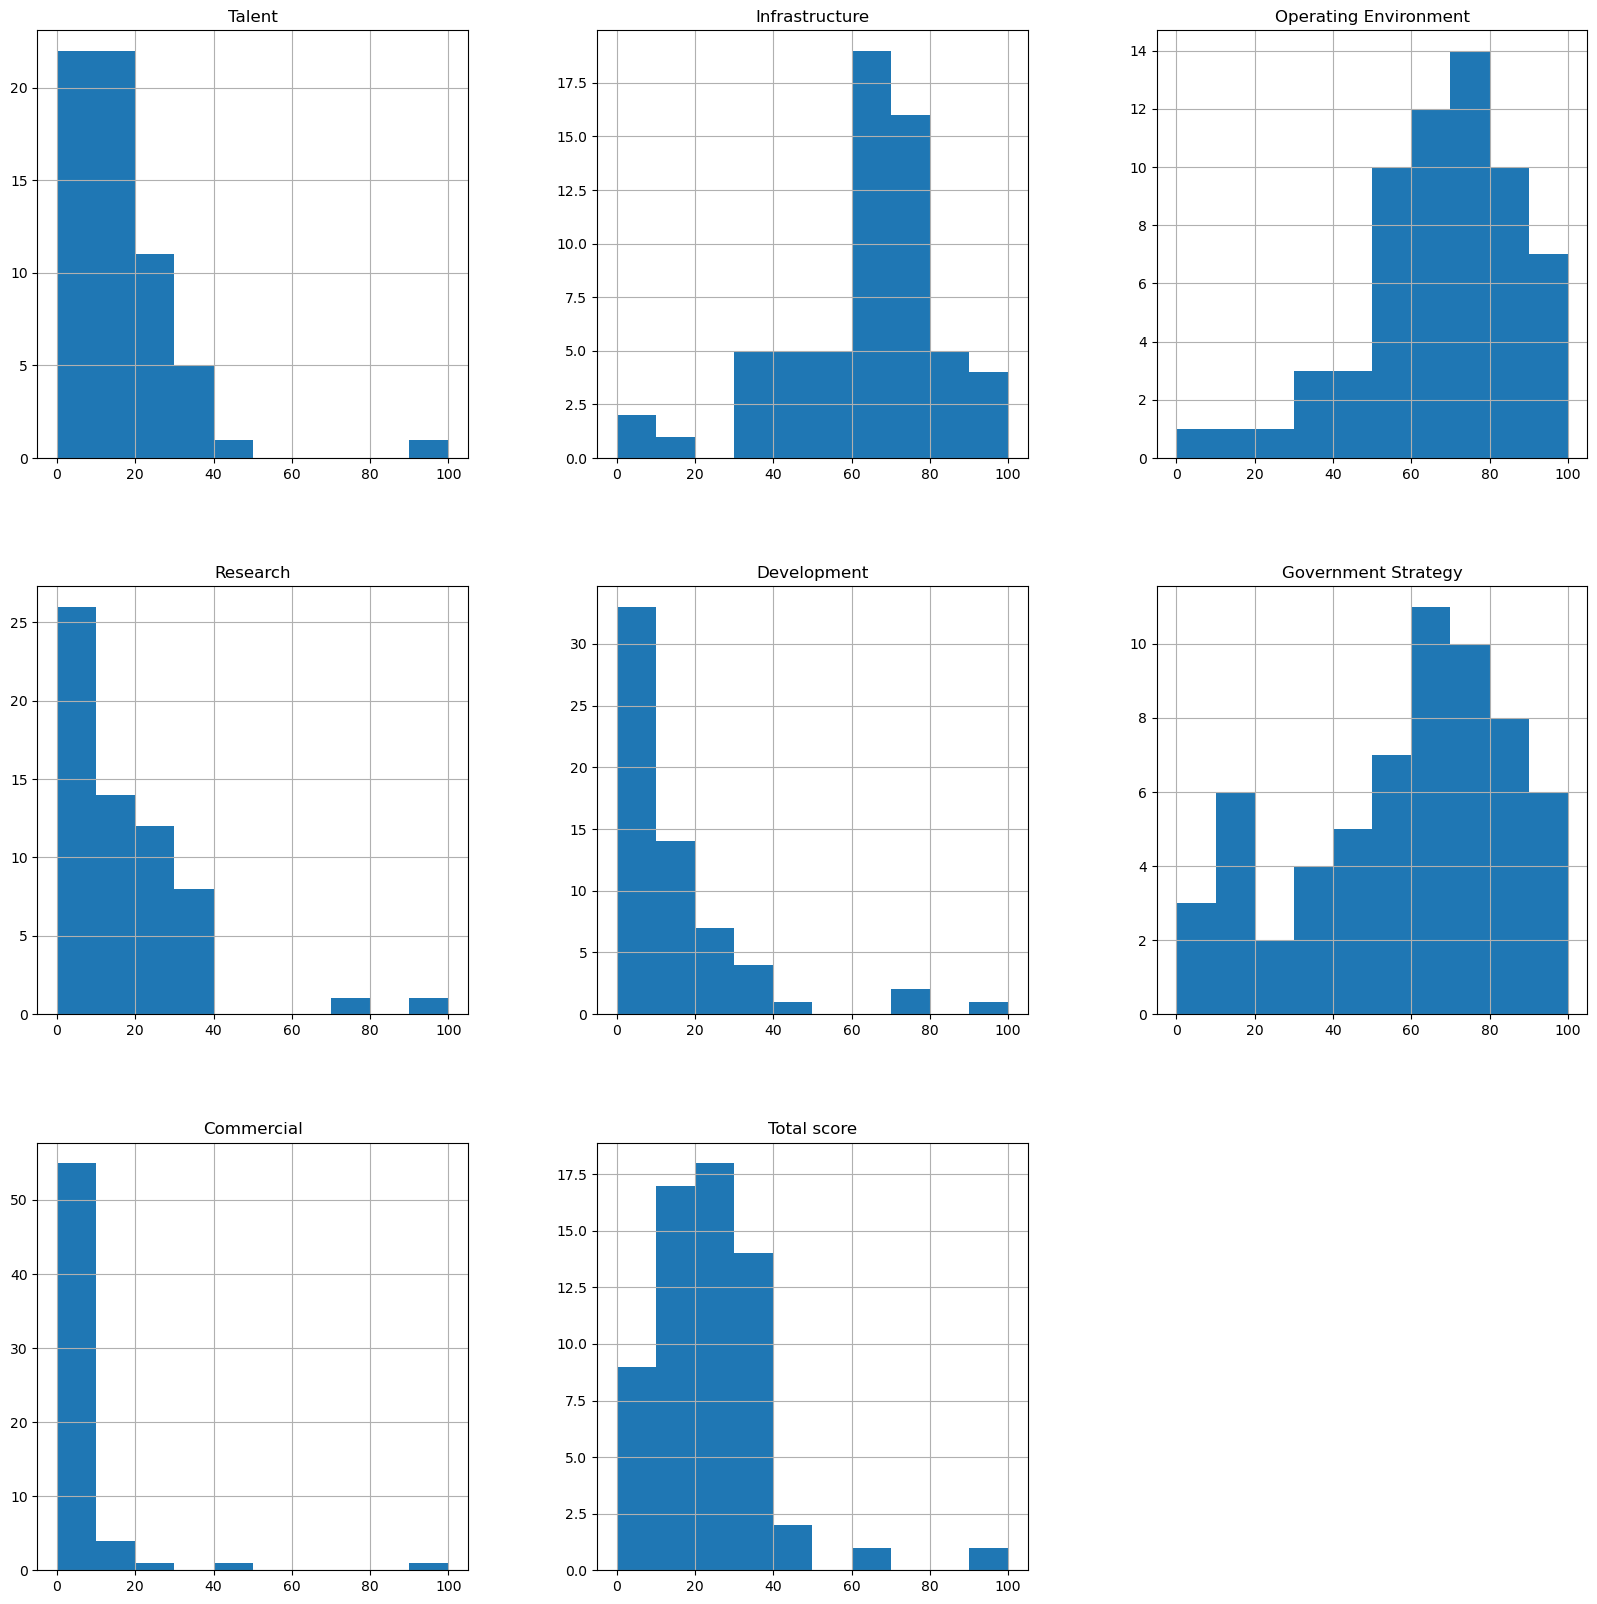

In [14]:
df.hist(figsize=(20,20))

*   **Talent** — скошено вправо.
*   **Infrastructure** — близко к норме.
*   **Operating Environment** — близко к норме.
*   **Research** — скошено вправо.
*   **Development** — скошено вправо.
*   **Government Strategy** — бимодальное.
*   **Commercial** — скошено вправо.
*   **Total score** — близко к норме.

In [9]:
from sklearn.preprocessing import LabelEncoder
data = df.copy()
le = LabelEncoder()
for col in df.columns:
    
    data[col] = le.fit_transform(df[col])
data


,Country,Talent,Infrastructure,Operating Environment,Research,Development,Government Strategy,Commercial,Total score,Region,Income group,Political regime
0,59,61,58,27,60,58,42,58,61,1,0,3
1,9,38,61,56,59,57,57,57,60,2,2,0
2,58,59,39,38,56,48,48,55,59,3,0,3
3,7,55,47,57,52,49,58,53,58,1,0,3
4,25,57,33,48,54,50,14,56,57,4,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...
57,50,12,4,3,2,10,11,1,4,2,1,2
58,13,2,7,0,12,14,32,6,3,4,1,1
59,28,1,2,2,1,33,1,6,2,0,1,1
60,36,5,0,9,4,15,1,7,1,0,1,1


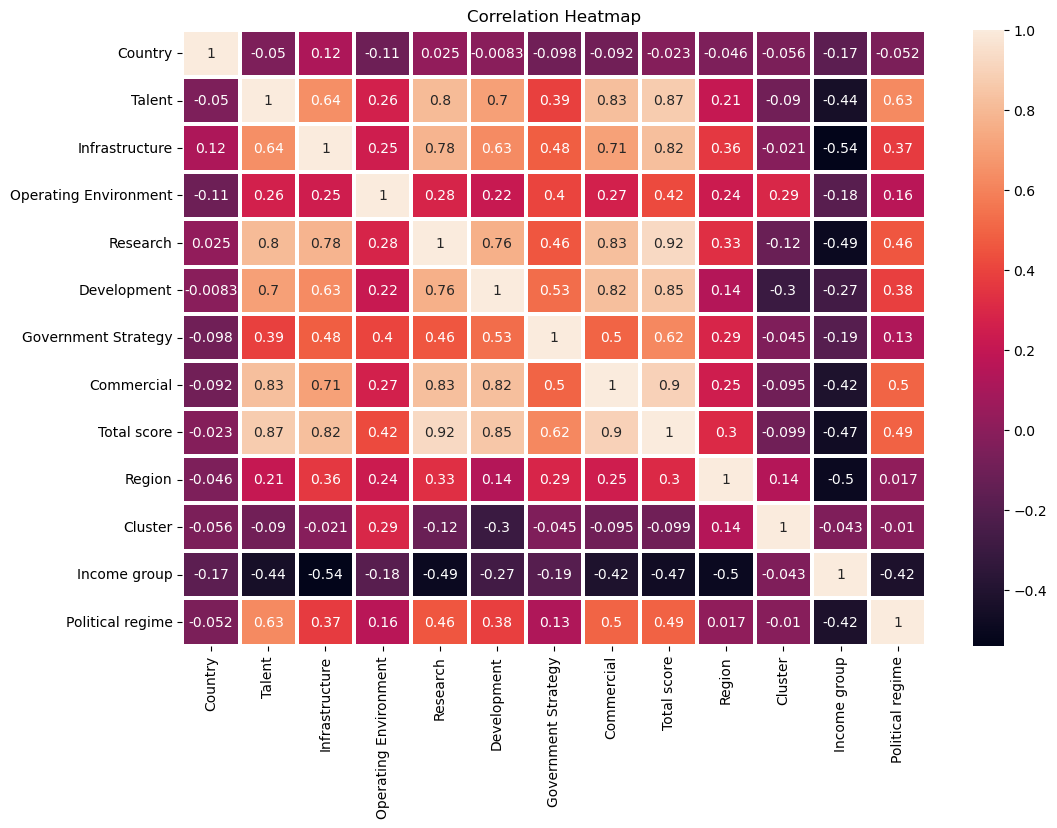

In [17]:

corr_matrix = data.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, linewidths=1.5)
plt.title('Correlation Heatmap')
plt.show()


##### По тепловой карте видим сильные корреляции:
*   Total score коррелирует с Research (0.92)
*   Total score коррелирует с Commercial (0.90)
*   Total score коррелирует с Talent (0.87)
*   Total score коррелирует с Development (0.85)
*   Research коррелирует с Commercial (0.83)
*   Commercial коррелирует с Talent (0.83)
*   Research коррелирует с Talent (0.80)
*   Commercial коррелирует с Development (0.82)

Видно самые высокие показатели корреляции у "Total score". Это мультиколлинеарность. Если оставить Total score, алгоритм кластеризации получит ту же информацию дважды и кластеризация по итогу просто перемешается 

#### Выводим признаки с высокой дисперсией

In [22]:
data.var().sort_values(ascending=False)


Country                  325.500000
Talent                   325.500000
Infrastructure           325.500000
Operating Environment    325.500000
Total score              325.500000
Research                 319.290323
Government Strategy      311.661819
Development              308.758593
Commercial               297.389741
Cluster                    1.678477
Region                     1.187996
Political regime           1.026177
Income group               0.546801
dtype: float64

####  Выделяем 7 подходящих признаков кластеризации  на основе дисперсии и корреляции

* Talent                 
* Infrastructure           
* Operating Environment
* Research
* Commercial
* Development
* Government Strategy



Загрузка конечного датасета

In [18]:
df.to_csv('ai_index.csv', index=False, encoding='utf-8')

## ОТЧЕТ

#### Загрузка данных

Данные были успешно загружены 

#### Описание структуры набора данных

Для каждого поля выведено тектовое описание


#### Разведочный анализ данных

Проверено количество пустых значений, дубликаты.  Проведены графические и статистические анализы данных на нормальное и равномерное распреление.


#### Формирование итогового набора данных

Удален  столбец кластер,загружен конечный датасет 

#### Важность признаков

Выделены 7 подходящих признаков кластеризации  на основе дисперсии и корреляции


### Кластеризация

In [18]:
from sklearn import metrics
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import SpectralClustering
import scipy.cluster.hierarchy as shc
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak")


In [156]:
X = data[['Development', 'Talent', 'Commercial', 
              'Research', 'Infrastructure', 'Government Strategy', 'Operating Environment']]

In [157]:
X.head(1)

,Development,Talent,Commercial,Research,Infrastructure,Government Strategy,Operating Environment
0,58,61,58,60,58,42,27


In [158]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled=scaler.fit_transform(X)

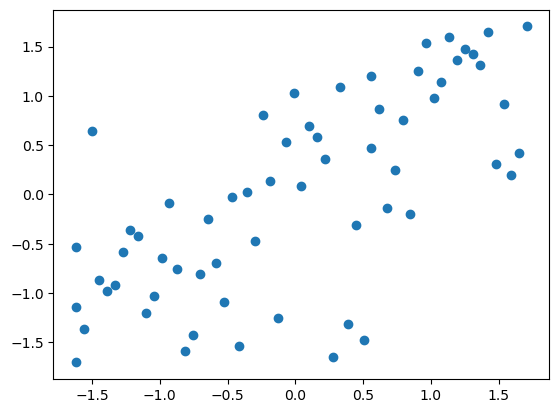

In [159]:
import matplotlib.pyplot as plt
plt.scatter(X_scaled[:,0],X_scaled[:,1])
plt.show()

In [160]:
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,11):
    Kmeans = KMeans(n_clusters=k,random_state=42)
    Kmeans.fit(X_scaled)
    wcss.append(Kmeans.inertia_)


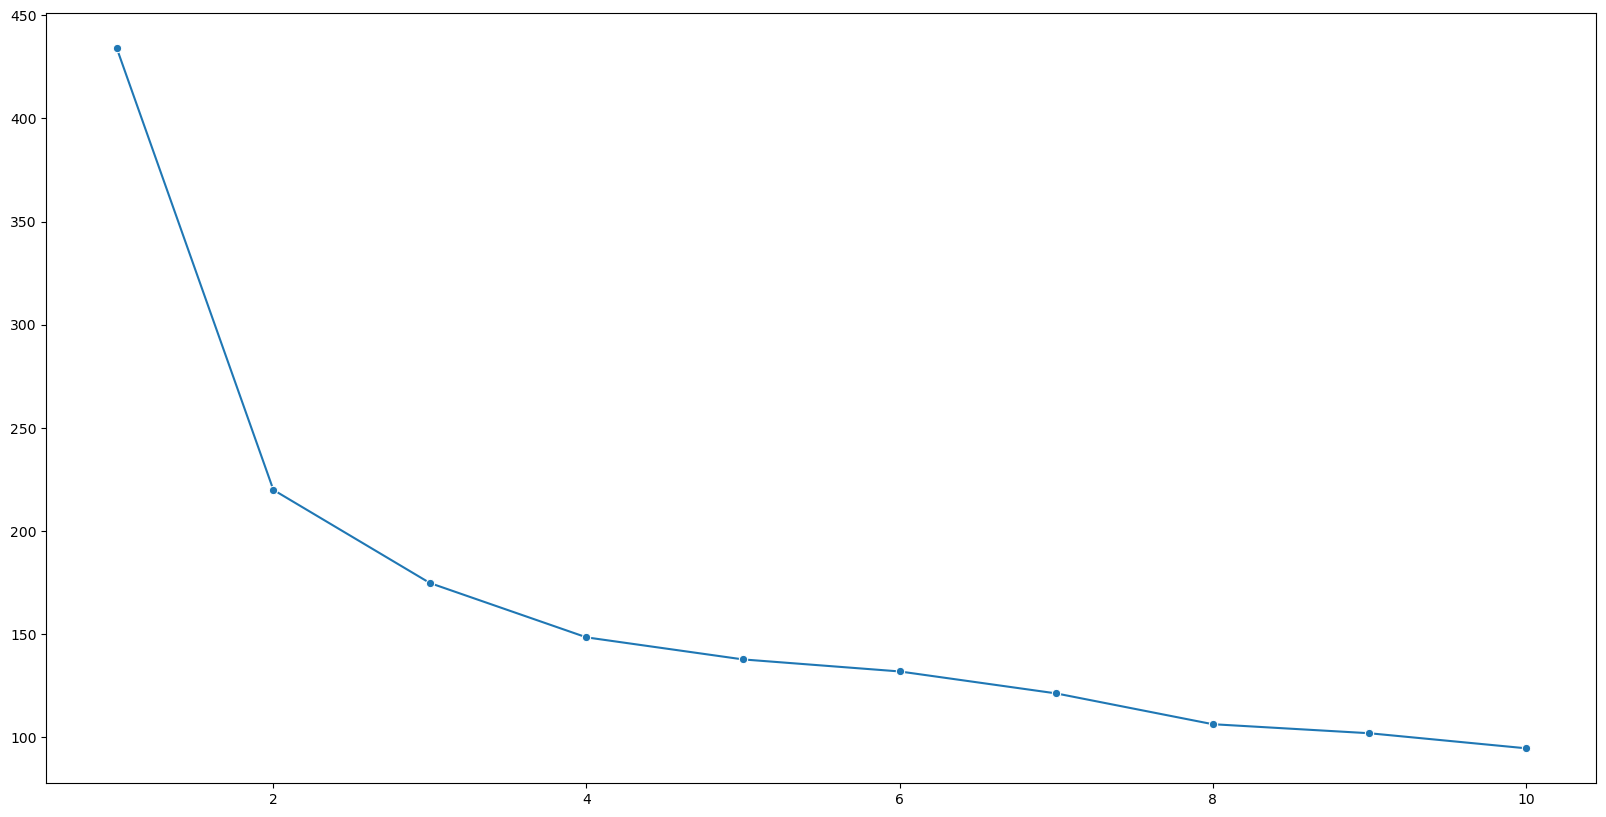

In [161]:
import matplotlib.pyplot as plt  
import seaborn as sns
plt.figure(figsize=(20,10))   
sns.lineplot(x=range(1,11), y=wcss, marker='o')
plt.show()

## Kmeans

In [162]:
cluster = KMeans(n_clusters=2)
kmeans = cluster.fit_predict(X_scaled)

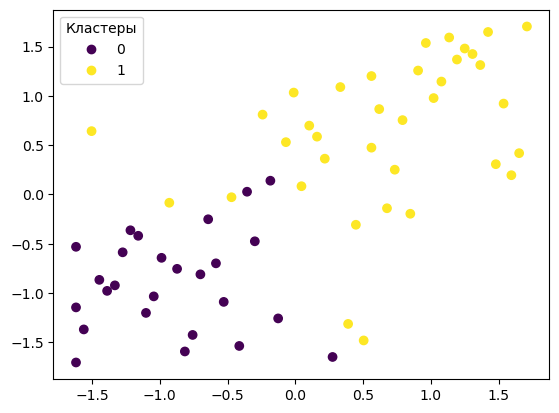

In [163]:
import matplotlib.pyplot as plt
plt.figure(dpi=100)

scatter=plt.scatter(X_scaled[:,0],X_scaled[:,1],c=kmeans)
plt.legend(*scatter.legend_elements(), title="Кластеры")

plt.show()

## Dbscan

In [179]:
from sklearn.cluster import DBSCAN

DbscanCluster = DBSCAN(eps=2.26449979, min_samples=22)
dbscan = DbscanCluster.fit_predict(X_scaled)


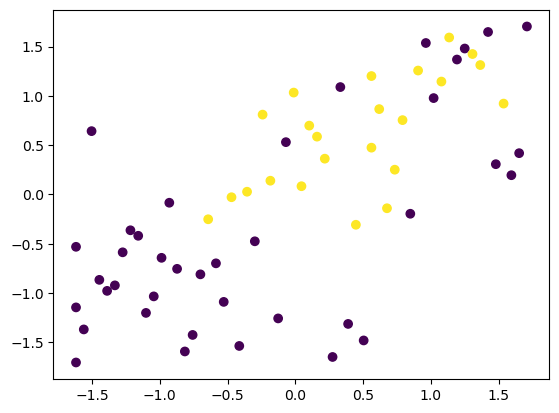

In [180]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=dbscan)
plt.show()

## GaussianMixture

In [166]:
from sklearn.cluster import DBSCAN
DbscanCluster = DBSCAN(eps=0.5, min_samples=20)
dbscan = DbscanCluster.fit_predict(X_scaled)
from sklearn.mixture import GaussianMixture
gmm = GaussianMixture(n_components=2, random_state=0)
gmm_pred = gmm.fit_predict(X_scaled)

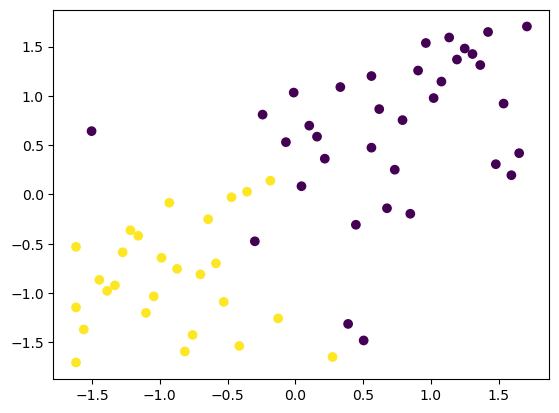

In [167]:
plt.scatter(X_scaled[:,0],X_scaled[:,1], c=gmm_pred)
plt.show()

### Оценка Kmeans

In [146]:
harabKmeans = metrics.calinski_harabasz_score(X_scaled, kmeans)
metrics.calinski_harabasz_score(X_scaled, kmeans)

57.370932345339895

In [168]:
silhKmeans = metrics.silhouette_score(X_scaled, kmeans)
metrics.silhouette_score(X_scaled, kmeans)

0.3950669199707808

### Оценка DBscan

In [181]:
harabDBscan = metrics.calinski_harabasz_score(X_scaled, dbscan)
metrics.calinski_harabasz_score(X_scaled, dbscan)

9.080671478074057

In [182]:
silhDBscan = metrics.silhouette_score(X_scaled, dbscan)
metrics.silhouette_score(X_scaled, dbscan)

0.12378836277658259

### Оценка GaussianMixture

In [183]:
harabgmm_pred = metrics.calinski_harabasz_score(X_scaled, gmm_pred)
metrics.calinski_harabasz_score(X_scaled, gmm_pred)

54.305949588477674

In [184]:
silhgmm_pred = metrics.silhouette_score(X_scaled, gmm_pred)
metrics.silhouette_score(X_scaled, gmm_pred)

0.37773043958395525

### Определение лучшего кластера



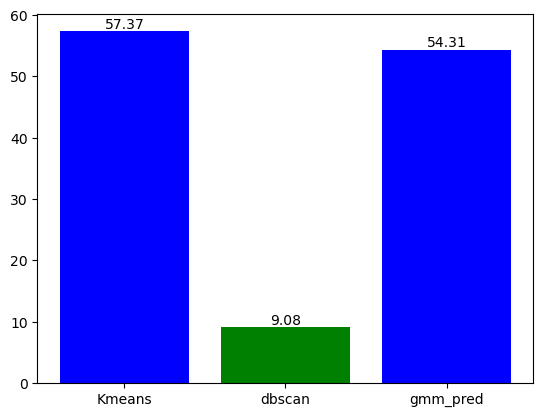

In [185]:

metrics = ['Kmeans', 'dbscan','gmm_pred']
scores = [harabKmeans, harabDBscan,harabgmm_pred]
plt.bar(metrics, scores, color=['blue', 'green'])
for i, v in enumerate(scores):
    plt.text(i, v, f'{v:.2f}', ha='center', va='bottom')
plt.show()

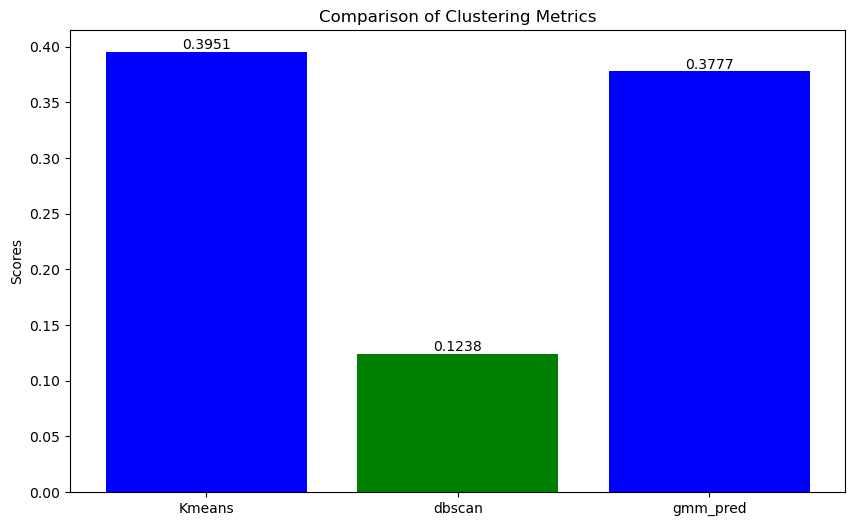

In [186]:
import matplotlib.pyplot as plt

metrics_s = ['Kmeans', 'dbscan','gmm_pred']
scores_s = [silhKmeans,silhDBscan,silhgmm_pred]


plt.figure(figsize=(10, 6))
plt.bar(metrics_s, scores_s, color=['blue', 'green'])
plt.ylabel('Scores')
plt.title('Comparison of Clustering Metrics')

for i, v in enumerate(scores_s):
    plt.text(i, v, f'{v:.4f}', ha='center', va='bottom')

plt.show()


### Кластеризация набора данных
Рассмотрены 3 вида кластеризации, выделено 3 кластера, по метрикам Калински-Харабаз и Силуэту выбран лучший алгоритм кластеризации  - Kmeans

